## Aim of Project

The aim of this project is to develop a machine learning model capable of accurately classifying wildlife species from camera trap images, 
thereby supporting automated wildlife monitoring and conservation efforts.

## Objectives

1. To build a computer vision model that can identify different animal species from images collected by camera traps.
2. To preprocess and organize raw image data into a structured format suitable for training deep learning models.
3. To reduce the need for manual labeling of large volumes of wildlife data, which is time-consuming and inefficient for conservation researchers.
4. To address challenges inherent in camera trap data, such as:
    - class imbalance (rare vs common species)
    - varying lighting conditions (day/night images)
    - presence of blank images (no animals)
5. To apply and evaluate deep learning techniques for improving classification performance.
6. To contribute toward scalable and automated tools that enable faster analysis of ecological data and support evidence-based conservation decisions


## Dataset Preparation

The dataset was obtained from the DrivenData Wildlife Conservation Image Classification competition:
https://www.drivendata.org/competitions/87/competition-image-classification-wildlife-conservation/

Initially, all training images were stored in a single directory (train_features), while labels were provided separately in a CSV file (train_labels.csv) using one-hot encoding across multiple animal classes.

To prepare the data for training:

The CSV file was parsed to identify the correct class for each image (based on columns with value 1.0).
File paths were dynamically constructed, and images were programmatically moved into their corresponding class folders (e.g., bird/, leopard/, etc.) using command-line scripting.
A validation process was performed step-by-step to ensure correct label extraction and file movement.
Images labeled as blank were excluded from class folders and later grouped into a separate blank/ directory.

This process transformed the dataset into a structured format where each class has its own folder, enabling efficient use with standard deep learning pipelines (e.g., PyTorch or TensorFlow).

In [1]:
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import PIL
import torch
import torchvision
from PIL import Image
from torchvision import transforms

In [20]:
# Assign path to multi-class training data

data_path = os.path.join("data", "data_class")
train_path = os.path.join(data_path, "train")

In [21]:
print("Data Path:", data_path)
print("Training data path:", train_path)

Data Path: data\data_class
Training data path: data\data_class\train


In [22]:
# create the list of the content of the training data directory
list_dir = os.listdir(train_path)

print("Directory length:", len(list_dir))
print(list_dir)

Directory length: 8
['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']


In [23]:
# How many images do we have for each class (how is our data distributed across the classes)

class_counts_dict = {}

for subdir in list_dir:
    dir = os.path.join(train_path, subdir)
    items = os.listdir(dir)
    num_of_items = len(items)
    class_counts_dict[subdir] = num_of_items

class_counts = pd.Series(class_counts_dict)

print("class_distributions type:", type(class_counts))
print("class_distributions shape:", class_counts.shape)
print(class_counts)



class_distributions type: <class 'pandas.core.series.Series'>
class_distributions shape: (8,)
antelope_duiker     2474
bird                1641
blank               2213
civet_genet         2423
hog                  978
leopard             2255
monkey_prosimian    2494
rodent              2013
dtype: int64


In [24]:
class_counts

antelope_duiker     2474
bird                1641
blank               2213
civet_genet         2423
hog                  978
leopard             2255
monkey_prosimian    2494
rodent              2013
dtype: int64

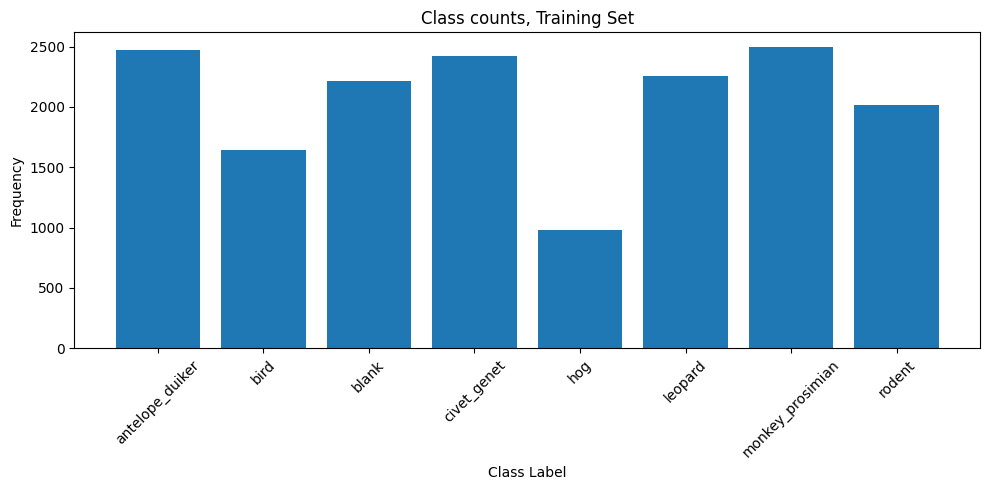

In [25]:
# Create a bar plot of class distributions
fig, ax = plt.subplots(figsize=(10, 5))


ax.bar(class_counts.index, class_counts.values)  # Write your code here
ax.set_xlabel("Class Label")
ax.set_ylabel("Frequency")
ax.set_title("Class counts, Training Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
print(os.path.exists(leopard_image_path))

True


In [27]:
# Define path for leopard image
leopard_image_path = os.path.join(train_path, "leopard", "ZJ000086.jpg")

# Define path for monkey image
monkey_prosimian_image_path = os.path.join(train_path, "monkey_prosimian", "ZJ000031.jpg")

print("leopard_image_path type:", type(leopard_image_path))
print(leopard_image_path)
print()
print("monkey_prosimian_image_path type:", type(monkey_prosimian_image_path))
print(leop_image_path)

leopard_image_path type: <class 'str'>
data\data_class\train\leopard\ZJ000086.jpg

monkey_prosimian_image_path type: <class 'str'>


NameError: name 'antelope_image_path' is not defined

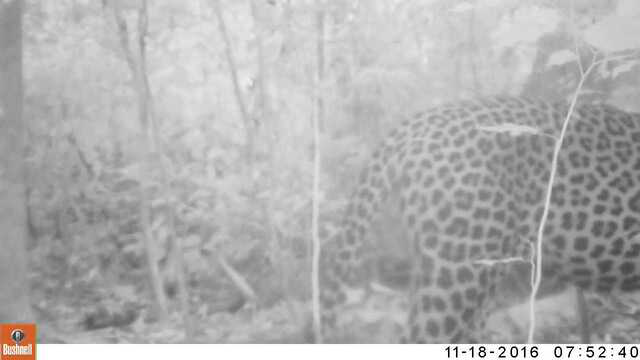

In [19]:
leopard_image_pil = Image.open(leopard_image_path)

#print("Leopard_image_pil type:", type(leopard_image_pil))
leopard_image_pil


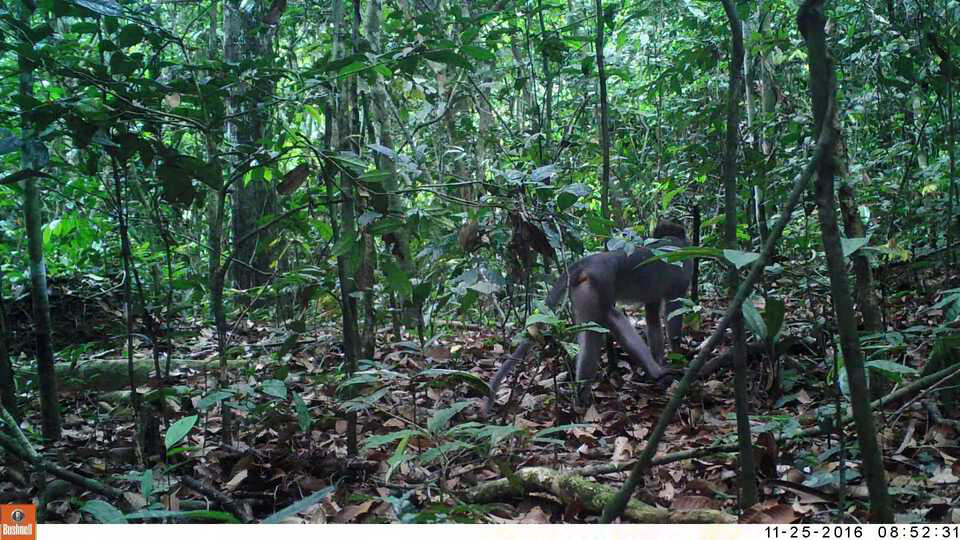

In [40]:
monkey_image_pil = Image.open(monkey_prosimian_image_path)

#print("Leopard_image_pil type:", type(leopard_image_pil))
monkey_image_pil

In [43]:
# Get image size for monkey
monkey_image_pil_size = monkey_image_pil.size

# Get image mode for monkey
monkey_image_pil_mode = monkey_image_pil.mode

# Print results
print("monkey_image_pil_size class:", type(monkey_image_pil_size))
print("monkey_image_pil_size length:", len(monkey_image_pil_size))
print("monkey image size:", monkey_image_pil_size)
print()
print("monkey_image_pil_mode class:", type(monkey_image_pil_mode))
print("monkey image mode:", monkey_image_pil_mode)

monkey_image_pil_size class: <class 'tuple'>
monkey_image_pil_size length: 2
monkey image size: (960, 540)

monkey_image_pil_mode class: <class 'str'>
monkey image mode: RGB


In [44]:
# Get image size for leopard
leopard_image_pil_size = leopard_image_pil.size

# Get image mode for leopard
leopard_image_pil_mode = leopard_image_pil.mode

# Print results
print("leopard_image_pil_size class:", type(leopard_image_pil_size))
print("leopard_image_pil_size length:", len(leopard_image_pil_size))
print("leopard image size:", leopard_image_pil_size)
print()
print("leopard_image_pil_mode class:", type(leopard_image_pil_mode))
print("leopard image mode:", leopard_image_pil_mode)

leopard_image_pil_size class: <class 'tuple'>
leopard_image_pil_size length: 2
leopard image size: (640, 360)

leopard_image_pil_mode class: <class 'str'>
leopard image mode: RGB


# Convert image data to tensors using the touchvision libray from pytorch

In [59]:
# start from converting the monkey image

monkey_tsr = transforms.ToTensor()(monkey_image_pil)

print("Monkey_tensor type:", type(monkey_tsr))
print("Monkey_tensor shape:", monkey_tsr.shape)
print("Monkey_tensor dtype:", monkey_tsr.dtype)
print("Monkey_tensor device:", monkey_tsr.device)


Monkey_tensor type: <class 'torch.Tensor'>
Monkey_tensor shape: torch.Size([3, 540, 960])
Monkey_tensor dtype: torch.float32
Monkey_tensor device: cpu


In [60]:
leopard_tsr = transforms.ToTensor()(leopard_image_pil)

print("leopard_tensor type:", type(leopard_tsr))
print("leopard_tensor shape:", leopard_tsr.shape)
print("leopard_tensor dtype:", leopard_tsr.dtype)
print("leopard_tensor device:", leopard_tsr.device)

leopard_tensor type: <class 'torch.Tensor'>
leopard_tensor shape: torch.Size([3, 360, 640])
leopard_tensor dtype: torch.float32
leopard_tensor device: cpu


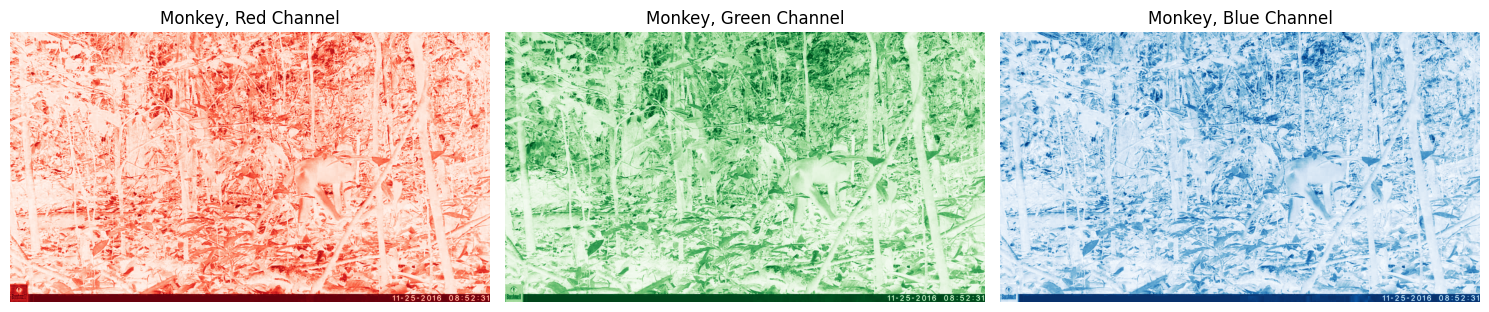

In [61]:
# Check the different image channels

# Create figure with 3 subplots
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5))

# Plot red channel
red_channel = monkey_tsr[0, :, :]
ax0.imshow(red_channel, cmap="Reds")
ax0.set_title("Monkey, Red Channel")
ax0.axis("off")

# Plot green channel
green_channel = monkey_tsr[1, :, :]
ax1.imshow(green_channel, cmap="Greens")
ax1.set_title("Monkey, Green Channel")
ax1.axis("off")


# Plot blue channel
blue_channel = monkey_tsr[2, :, :]
ax2.imshow(blue_channel, cmap="Blues")
ax2.set_title("Monkey, Blue Channel")
ax2.axis("off")


plt.tight_layout();

In [62]:
# Calculate the mean per color channel

avg_channel_values = monkey_tsr.mean(dim=[1, 2])
print("average channel values of monkey tensor RGB:", avg_channel_values)

average channel values of monkey tensor RGB: tensor([0.2588, 0.3477, 0.2984])
